# Inventory Risk - Safety Stock & Reorder Point

Turning the forecast into an actual inventory decision. A point forecast doesn't tell you how much buffer stock to hold - you need the uncertainty around it.

safety stock = Z * residual_std * sqrt(lead_time_days)
reorder point = avg_daily_demand * lead_time_days + safety_stock

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import sys
sys.path.insert(0, '../src')
from features import FEATURE_COLUMNS

model = joblib.load('../models/demand_model.joblib')  # now {'clf': ..., 'reg': ..., 'threshold': ...} from the gated hurdle model
df = pd.read_csv('../data/processed/model_ready_test.csv',
                  dtype={'stock_code': str},
                  parse_dates=['sale_date'])
print(f"{len(df):,} test rows, {df['stock_code'].nunique():,} SKUs")

C:\Users\lenovo\AppData\Local\Temp\ipykernel_25480\934062334.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/model_ready_test.csv',


332,891 test rows, 3,193 SKUs


## Forecast residuals

Using the model's actual errors on test data instead of assuming some fixed uncertainty number.

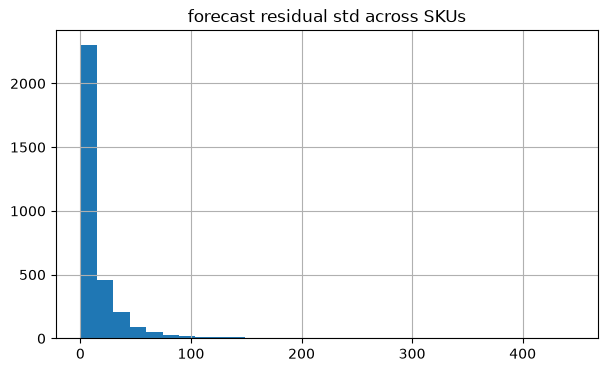

In [2]:
p_nonzero = model['clf'].predict_proba(df[FEATURE_COLUMNS])[:, 1]
mag = np.clip(model['reg'].predict(df[FEATURE_COLUMNS]), 0, None)

df['forecast'] = np.where(p_nonzero > model['threshold'], mag, 0.0)
df['residual'] = df['units_sold'] - df['forecast']

sku_std = df.groupby('stock_code')['residual'].std().rename('residual_std')
sku_avg = df.groupby('stock_code')['forecast'].mean().rename('avg_daily_forecast')

sku_std.dropna().hist(bins=30, figsize=(7,4))
plt.title('forecast residual std across SKUs')
plt.show()

## Safety stock at 90/95/99% service levels

In [3]:
LEAD_TIME_DAYS = 7  # assumption, not measured
z_scores = {'90%': 1.28, '95%': 1.65, '99%': 2.33}

inv = pd.concat([sku_avg, sku_std], axis=1).dropna()
for label, z in z_scores.items():
    inv[f'safety_stock_{label}'] = z * inv['residual_std'] * np.sqrt(LEAD_TIME_DAYS)

inv['reorder_point_95%'] = inv['avg_daily_forecast'] * LEAD_TIME_DAYS + inv['safety_stock_95%']
inv.sort_values('safety_stock_95%', ascending=False).head(10)

,avg_daily_forecast,residual_std,safety_stock_90%,safety_stock_95%,safety_stock_99%,reorder_point_95%
stock_code,,,,,,
84077,79.620025,446.022303,1510.482040,1947.105755,2749.549339,2504.445932
23084,28.141792,438.531426,1485.113722,1914.404408,2703.371073,2111.396949
22197,76.865210,386.040535,1307.350080,1685.255963,2379.785693,2223.312430
23582,28.514876,357.761660,1211.581929,1561.804830,2205.457730,1761.408966
16014,0.000000,344.543151,1166.816632,1504.099564,2123.970900,1504.099564
21915,33.400286,283.663073,960.642492,1238.328212,1748.669536,1472.130217
20971,18.887784,269.448631,912.504408,1176.275213,1661.043180,1308.489699
21787,8.628178,211.755385,717.122673,924.415946,1305.387366,984.813189
85099B,106.776309,202.709015,686.486583,884.924111,1249.620108,1632.358274


## Stockout risk flag

Simple rule: any forecast uncertainty at all means a zero-safety-stock policy risks running out. No real on-hand inventory data exists here so this is a proxy, not the real thing.

In [4]:
inv['lead_time_demand'] = inv['avg_daily_forecast'] * LEAD_TIME_DAYS
inv['at_risk_without_safety_stock'] = inv['residual_std'] > 0

n_at_risk = inv['at_risk_without_safety_stock'].sum()
print(f"{n_at_risk} of {len(inv)} SKUs would be at stockout risk with zero safety stock")

3057 of 3189 SKUs would be at stockout risk with zero safety stock


## Save

In [5]:
out = inv.reset_index()[['stock_code','avg_daily_forecast','residual_std',
                          'safety_stock_90%','safety_stock_95%','safety_stock_99%','reorder_point_95%']]
out.to_csv('../data/processed/inventory_risk.csv', index=False)
print(f"saved inventory_risk.csv, {len(out)} SKUs")

saved inventory_risk.csv, 3189 SKUs


## Notes

- Lead time (7 days) and service levels are assumptions, not measured - real deployment would use actual supplier lead times.
- Safety stock scales with the model's actual test-set error, not a guessed number.
- Stockout flag is a simple proxy since there's no real on-hand inventory data in this dataset.